## Preliminaries

In [1]:
# pip install matplotlib pandas scikit-learn seaborn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import kendalltau
from sklearn.metrics import mean_absolute_error

## Data Loading

In [3]:
predictions = pd.read_csv("predictions/pm100/predictions.csv")

In [4]:
w_66k = pd.read_csv('workloads/pm100/pm100.swf', sep="\t", header=None)

workload_column_names = [
    "Job Number", "Submit Time", "Wait Time", "Run Time",
    "Number of Allocated Nodes", "Average CPU Time Used",
    "Used Memory", "Requested Number of Nodes",
    "Requested Time", "Requested Memory", "Status",
    "User ID", "Group ID", "Executable Number",
    "Queue Number", "Partition Number",
    "Preceding Job Number", "Think Time from Preceding Job"
]

w_66k.columns = workload_column_names

predictions["nodes"] = w_66k["Number of Allocated Nodes"]

In [5]:
predictions

,job_id,user_id,time_submit,gt_runtime,pred_runtime_user,pred_runtime_heuristic,pred_runtime_dt_fs1,pred_runtime_dt_fs2,pred_runtime_rnp_fs1,pred_runtime_rnp_fs2,pred_runtime_knn_fs1,pred_runtime_knn_fs2,pred_runtime_ora,pred_runtime_knn_c4_fs1,pred_runtime_knn_c4_fs2,pred_runtime_knn_c7_fs1,pred_runtime_knn_c7_fs2,nodes
0,5154115,1711,11480812,4578,14400,1582,3488,4571,3722,3062,3330,4527,4444,Medium,Medium,Medium,Medium,1
1,5640678,1711,11480812,4614,14400,1582,3488,4454,3722,3029,3330,4503,4213,Medium,Medium,Medium,Medium,1
2,1597511,1711,11480812,4282,14400,1583,3488,4417,3722,3138,3330,4477,4353,Medium,Medium,Medium,Medium,1
3,4698474,1711,11480812,4534,14400,1583,3488,4486,3722,3092,3330,4502,4353,Medium,Medium,Medium,Medium,1
4,6129873,1711,11480812,4140,14400,1582,3488,4564,3722,3088,3330,4506,4649,Medium,Medium,Medium,Medium,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66751,3214055,8,13832570,4,300,300,3,2,3,3,177,72,4,Short,Very-Short,Short,Very-Short,4
66752,558069,8,13833191,2,300,300,3,3,3,3,177,72,10,Short,Very-Short,Short,Very-Short,4
66753,1997479,8,13833813,3,300,300,3,2,3,3,177,72,3,Short,Very-Short,Short,Very-Short,4
66754,4424415,8,13834310,3,300,300,3,3,3,3,177,72,300,Short,Very-Short,Short,Very-Short,4


In [6]:
w_1800_1 = pd.read_csv('workloads/pm100/pm100_1800_1.swf', sep="\t", header=None)
w_1800_2 = pd.read_csv('workloads/pm100/pm100_1800_2.swf', sep="\t", header=None)
w_1800_3 = pd.read_csv('workloads/pm100/pm100_1800_3.swf', sep="\t", header=None)
w_1800_4 = pd.read_csv('workloads/pm100/pm100_1800_4.swf', sep="\t", header=None)
w_1800_5 = pd.read_csv('workloads/pm100/pm100_1800_5.swf', sep="\t", header=None)

## Job Classes

In [7]:
def assign_job_classes(df, runtime_col="gt_runtime", nodes_col="nodes"):

    df = df.copy()
    
    # --- Duration classification
    def duration_class(runtime):
        if 1 <= runtime < 300:
            return "Short"
        elif 300 <= runtime < 7200:
            return "Medium"
        elif 7200 <= runtime <= 86400:
            return "Long"
        else:
            return None

    # --- Size classification
    def size_class(nodes):
        if 1 <= nodes < 980/200:
            return "Small"
        elif 980/200 <= nodes < 980/100*3:
            return "Medium"
        elif 980/100*3 <= nodes <= 980:
            return "Large"
        else:
            return None

    # Apply classifications
    df["size_class"] = df[nodes_col].apply(size_class)
    df["duration_class"] = df[runtime_col].apply(duration_class)

    return df


def plot_job_classes(df, runtime_col="gt_runtime", nodes_col="nodes"):

    plt.figure(figsize=(8, 6))

    # -----------------------
    # STYLE MAPS
    # -----------------------
    duration_colors = {
        "Short": "tab:blue",
        "Medium": "tab:orange",
        "Long": "tab:green"
    }

    size_markers = {
        "Small": "o",
        "Medium": "^",
        "Large": "s"
    }

    total_jobs = len(df)

    # -----------------------
    # PLOT COMBINATIONS
    # -----------------------
    for d_class, color in duration_colors.items():
        for s_class, marker in size_markers.items():

            subset = df[
                (df["duration_class"] == d_class) &
                (df["size_class"] == s_class)
            ]

            if subset.empty:
                continue

            count = len(subset)
            perc = (count / total_jobs) * 100 if total_jobs > 0 else 0

            label = f"{d_class} | {s_class} (n={count}, {perc:.1f}%)"

            plt.scatter(
                subset[runtime_col],
                subset[nodes_col],
                color=color,
                marker=marker,
                label=label,
                alpha=0.6,
                s=10
            )

    # -----------------------
    # AXES
    # -----------------------
    ticks = np.arange(0, 86401, 3600)
    plt.xlim(0, max(ticks))
    plt.xticks(ticks=ticks, labels=(ticks / 3600).astype(int))
    plt.axvline(300, linestyle="--", alpha=0.5)
    plt.axvline(7200, linestyle="--", alpha=0.5)
    plt.xlabel("Runtime (hours)")
    
    
    ticks = np.arange(0, 257, 16)
    plt.ylim(0, max(ticks))
    plt.yticks(ticks=ticks, labels=ticks.astype(int))
    plt.axhline(8, linestyle="--", alpha=0.5)
    plt.axhline(32, linestyle="--", alpha=0.5)
    plt.ylabel("Nodes")
    
    plt.title("Job Classes (Duration vs Size)")
    plt.grid(True)
    
    # -----------------------
    # LEGEND
    # -----------------------
    # --- duration legend (colors)
    duration_handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=8, label=cls)
        for cls, color in duration_colors.items()
    ]
    
    # --- size legend (markers)
    size_handles = [
        plt.Line2D([0], [0], marker=marker, color='black',
                   linestyle='None', markersize=8, label=cls)
        for cls, marker in size_markers.items()
    ]
    
    # First legend (top-right)
    legend1 = plt.legend(
        handles=duration_handles,
        title="Duration",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0)
    )
    
    # Second legend (just below first)
    legend2 = plt.legend(
        handles=size_handles,
        title="Size",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.70)  # 👈 adjust if needed
    )
    
    plt.gca().add_artist(legend1)

    plt.show()

        # =======================
    # MATRIX PLOT (PERCENTAGES)
    # =======================
    
    duration_classes = ["Short", "Medium", "Long"]
    size_classes = ["Small", "Medium", "Large"]
    
    # count matrix
    matrix = pd.DataFrame(0, index=duration_classes, columns=size_classes)
    
    for d in duration_classes:
        for s in size_classes:
            matrix.loc[d, s] = len(df[
                (df["duration_class"] == d) &
                (df["size_class"] == s)
            ])
    
    total_jobs = matrix.values.sum()
    
    # convert to percentage
    perc_matrix = (matrix / total_jobs) * 100
    
    # add totals
    perc_matrix["Total"] = perc_matrix.sum(axis=1)
    perc_matrix.loc["Total"] = perc_matrix.sum(axis=0)
    
    # enforce 100% in bottom-right
    perc_matrix.loc["Total", "Total"] = 100.0
    
    # -----------------------
    # PLOT MATRIX
    # -----------------------
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    
    im = ax.imshow(perc_matrix.values, cmap="Blues")
    
    # ticks
    ax.set_xticks(np.arange(len(perc_matrix.columns)))
    ax.set_yticks(np.arange(len(perc_matrix.index)))
    
    ax.set_xticklabels(perc_matrix.columns)
    ax.set_yticklabels(perc_matrix.index)
    
    ax.set_xlabel("Size Class")
    ax.set_ylabel("Duration Class")
    ax.set_title("Job Distribution (%)")
    
    # annotate cells
    for i in range(len(perc_matrix.index)):
        for j in range(len(perc_matrix.columns)):
            val = perc_matrix.iloc[i, j]
            ax.text(j, i, f"{val:.2f}%",
                    ha="center", va="center", color="black")
    
    # colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Percentage of Jobs")
    
    plt.show()

In [8]:
predictions = assign_job_classes(predictions)

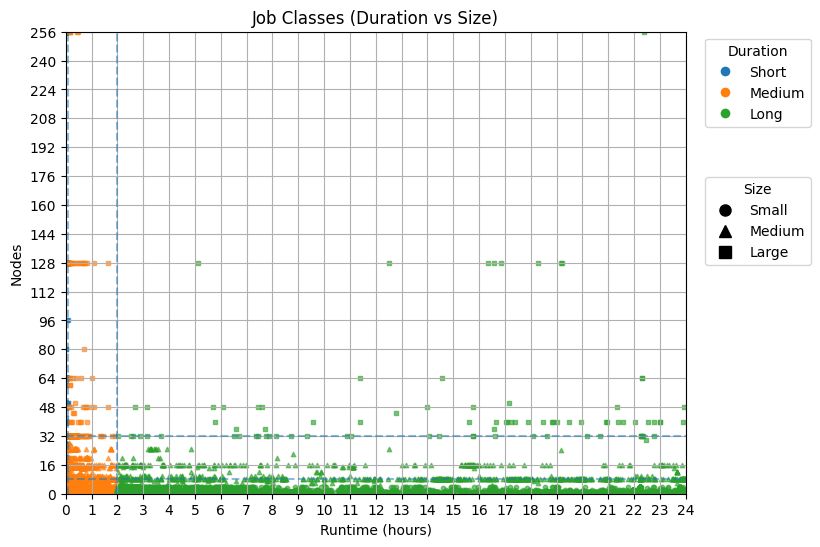

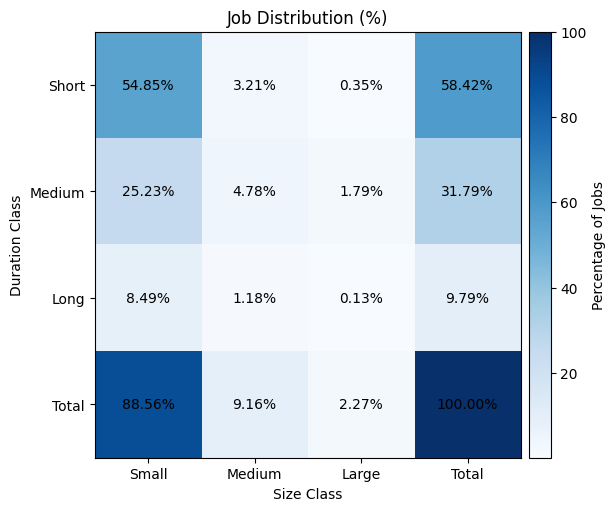

In [9]:
plot_job_classes(predictions)

## Data Filtering

In [10]:
pred_w_1800_1 = predictions[predictions["job_id"].isin(w_1800_1[0].values)]
pred_w_1800_2 = predictions[predictions["job_id"].isin(w_1800_2[0].values)]
pred_w_1800_3 = predictions[predictions["job_id"].isin(w_1800_3[0].values)]
pred_w_1800_4 = predictions[predictions["job_id"].isin(w_1800_4[0].values)]
pred_w_1800_5 = predictions[predictions["job_id"].isin(w_1800_5[0].values)]

## Metrics Helpers

In [11]:
def mean_average_percentage_error(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Avoid division by zero
    mask = (y_true > 0) & (y_pred > 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mape

In [12]:
def estimation_accuracy(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Avoid division by zero
    mask = (y_true > 0) & (y_pred > 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    ea = np.where(y_pred <= y_true,
                  y_pred / y_true,
                  y_true / y_pred)

    return float(np.mean(ea))

In [13]:
def convert_to_hms(time_value, unit="seconds"):
    if unit == "minutes":
        time_value *= 60  # Convert minutes to seconds
    hours, remainder = divmod(time_value, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{int(hours):02}:{int(minutes):02}:{int(seconds):02}"

In [14]:
def compute_error_metrics(df, pred_col, gt_col="gt_runtime"):
    err = df[pred_col] - df[gt_col]

    over = err[err > 0]
    exact = err[err == 0]
    under = err[err < 0]

    mae_over = over.mean() if len(over) > 0 else 0
    mae_under = np.abs(under.mean()) if len(under) > 0 else 0

    PJO = len(over) / len(err)
    PJE = len(exact) / len(err)
    PJU = len(under) / len(err)

    return mae_over, mae_under, PJO, PJU, PJE

In [15]:
def compute_metrics_per_class(df, pred_col, gt_col="gt_runtime"):

    results = {}

    for cls in df["duration_class"].unique():
        subset = df[df["duration_class"] == cls]

        err = subset[pred_col] - subset[gt_col]

        over = err[err > 0]
        exact = err[err == 0]
        under = err[err < 0]
        
        if len(subset) == 0:
            results[f"MAE_{cls[0]}"] = np.nan
            results[f"PJO_{cls[0]}"] = np.nan
            results[f"PJE_{cls[0]}"] = np.nan
            results[f"PJU_{cls[0]}"] = np.nan
        else:
            results[f"MAE_{cls[0]}"] = mean_absolute_error(subset[gt_col], subset[pred_col])
            results[f"MAE_OVER_{cls[0]}"] = over.mean() if len(over) > 0 else 0
            results[f"MAE_UNDER_{cls[0]}"] = np.abs(under.mean()) if len(under) > 0 else 0
            results[f"PJO_{cls[0]}"] = len(over) / len(err)
            results[f"PJE_{cls[0]}"] = len(exact) / len(err)
            results[f"PJU_{cls[0]}"] = len(under) / len(err)

    return results['MAE_S'], results['MAE_OVER_S'], results['MAE_UNDER_S'], results['PJO_S'], results['PJE_S'], results['PJU_S'], results['MAE_M'], results['MAE_OVER_M'], results['MAE_UNDER_M'], results['PJO_M'], results['PJE_M'], results['PJU_M'], results['MAE_L'], results['MAE_OVER_L'], results['MAE_UNDER_L'], results['PJO_L'], results['PJE_L'], results['PJU_L']

In [16]:
# gt_runtime pred_runtime_user pred_runtime_heuristic pred_runtime_dt_fs2 pred_runtime_rnp_fs2 pred_runtime_knn_fs2 pred_runtime_ora

## Complete Dataset

### Metric Computation

In [17]:
mae_usr = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_user)
mae_heu = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_heuristic)
mae_dt  = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_dt_fs2)
mae_rnp = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_rnp_fs2)
mae_knn = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_knn_fs2)
mae_llm = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_ora)

In [18]:
ea_usr = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_user)
ea_heu = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_heuristic)
ea_dt  = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_dt_fs2)
ea_rnp = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_rnp_fs2)
ea_knn = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_knn_fs2)
ea_llm = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_ora)

In [19]:
mape_usr = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_user)
mape_heu = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_heuristic)
mape_dt  = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_dt_fs2)
mape_rnp = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_rnp_fs2)
mape_knn = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_knn_fs2)
mape_llm = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_ora)

In [20]:
tau_usr, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_user)
tau_heu, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_heuristic)
tau_dt , _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_dt_fs2)
tau_rnp, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_rnp_fs2)
tau_knn, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_knn_fs2)
tau_llm, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_ora)

In [21]:
mae_over_usr, mae_under_usr, pjo_usr, pju_usr, pje_usr = compute_error_metrics(predictions, "pred_runtime_user")
mae_over_act, mae_under_act, pjo_act, pju_act, pje_act = compute_error_metrics(predictions, "gt_runtime")
mae_over_heu, mae_under_heu, pjo_heu, pju_heu, pje_heu = compute_error_metrics(predictions, "pred_runtime_heuristic")
mae_over_dt, mae_under_dt, pjo_dt, pju_dt, pje_dt = compute_error_metrics(predictions, "pred_runtime_dt_fs2")
mae_over_rnp, mae_under_rnp, pjo_rnp, pju_rnp, pje_rnp = compute_error_metrics(predictions, "pred_runtime_rnp_fs2")
mae_over_knn, mae_under_knn, pjo_knn, pju_knn, pje_knn = compute_error_metrics(predictions, "pred_runtime_knn_fs2")
mae_over_llm, mae_under_llm, pjo_llm, pju_llm, pje_llm = compute_error_metrics(predictions, "pred_runtime_ora")

In [22]:
mae_s_usr, mae_over_s_usr, mae_under_s_usr, pjo_s_usr, pje_s_usr, pju_s_usr, mae_m_usr, mae_over_m_usr, mae_under_m_usr, pjo_m_usr, pje_m_usr, pju_m_usr, mae_l_usr, mae_over_l_usr, mae_under_l_usr, pjo_l_usr, pje_l_usr, pju_l_usr = compute_metrics_per_class(predictions, "pred_runtime_user")
mae_s_heu, mae_over_s_heu, mae_under_s_heu, pjo_s_heu, pje_s_heu, pju_s_heu, mae_m_heu, mae_over_m_heu, mae_under_m_heu, pjo_m_heu, pje_m_heu, pju_m_heu, mae_l_heu, mae_over_l_heu, mae_under_l_heu, pjo_l_heu, pje_l_heu, pju_l_heu = compute_metrics_per_class(predictions, "pred_runtime_heuristic")
mae_s_dt, mae_over_s_dt, mae_under_s_dt, pjo_s_dt, pje_s_dt, pju_s_dt, mae_m_dt, mae_over_m_dt, mae_under_m_dt, pjo_m_dt, pje_m_dt, pju_m_dt, mae_l_dt, mae_over_l_dt, mae_under_l_dt, pjo_l_dt, pje_l_dt, pju_l_dt = compute_metrics_per_class(predictions, "pred_runtime_dt_fs2")
mae_s_rnp, mae_over_s_rnp, mae_under_s_rnp, pjo_s_rnp, pje_s_rnp, pju_s_rnp, mae_m_rnp, mae_over_m_rnp, mae_under_m_rnp, pjo_m_rnp, pje_m_rnp, pju_m_rnp, mae_l_rnp, mae_over_l_rnp, mae_under_l_rnp, pjo_l_rnp, pje_l_rnp, pju_l_rnp = compute_metrics_per_class(predictions, "pred_runtime_rnp_fs2")
mae_s_knn, mae_over_s_knn, mae_under_s_knn, pjo_s_knn, pje_s_knn, pju_s_knn, mae_m_knn, mae_over_m_knn, mae_under_m_knn, pjo_m_knn, pje_m_knn, pju_m_knn, mae_l_knn, mae_over_l_knn, mae_under_l_knn, pjo_l_knn, pje_l_knn, pju_l_knn = compute_metrics_per_class(predictions, "pred_runtime_knn_fs2")
mae_s_llm, mae_over_s_llm, mae_under_s_llm, pjo_s_llm, pje_s_llm, pju_s_llm, mae_m_llm, mae_over_m_llm, mae_under_m_llm, pjo_m_llm, pje_m_llm, pju_m_llm, mae_l_llm, mae_over_l_llm, mae_under_l_llm, pjo_l_llm, pje_l_llm, pju_l_llm = compute_metrics_per_class(predictions, "pred_runtime_ora")

### Details

In [23]:
res = pd.DataFrame()
res['Workload'] = ('Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal')
res['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res['Average Error'] = (convert_to_hms(mae_usr), convert_to_hms(0), convert_to_hms(mae_heu), convert_to_hms(mae_dt), convert_to_hms(mae_rnp), convert_to_hms(mae_knn), convert_to_hms(mae_llm))
res['MAE'] = (mae_usr, 0, mae_heu, mae_dt, mae_rnp, mae_knn, mae_llm)
res['MAPE'] = (mape_usr/1000, 0, mape_heu/1000, mape_dt/1000, mape_rnp/1000, mape_knn/1000, mape_llm/1000)
res['EA'] = (ea_usr, 1, ea_heu, ea_dt, ea_rnp, ea_knn, ea_llm)
res['TAU'] = (tau_usr, 1, tau_heu, tau_dt, tau_rnp, tau_knn, tau_llm)

res["MAE_OVER"] = (mae_over_usr, 0, mae_over_heu, mae_over_dt, mae_over_rnp, mae_over_knn, mae_over_llm)
res["MAE_UNDER"] = (mae_under_usr, 0, mae_under_heu, mae_under_dt, mae_under_rnp, mae_under_knn, mae_under_llm)

res["%_OVER"] = (pjo_usr, pjo_act, pjo_heu, pjo_dt, pjo_rnp, pjo_knn, pjo_llm)
res["%_UNDER"] = (pju_usr, pjo_act, pju_heu, pju_dt, pju_rnp, pju_knn, pju_llm)
res["%_EXACT"] = (pje_usr, pje_act, pje_heu, pje_dt, pje_rnp, pje_knn, pje_llm)

# ------------------------------------------------------------------------------------------------------------------------ #

res['MAE_S'] = (mae_s_usr, 0, mae_s_heu, mae_s_dt, mae_s_rnp, mae_s_knn, mae_s_llm)
res["MAE_OVER_S"] = (mae_over_s_usr, 0, mae_over_s_heu, mae_over_s_dt, mae_over_s_rnp, mae_over_s_knn, mae_over_s_llm)
res["MAE_UNDER_S"] = (mae_under_s_usr, 0, mae_under_s_heu, mae_under_s_dt, mae_under_s_rnp, mae_under_s_knn, mae_under_s_llm)

res["%_OVER_S"] = (pjo_s_usr, 0, pjo_s_heu, pjo_s_dt, pjo_s_rnp, pjo_s_knn, pjo_s_llm)
res["%_UNDER_S"] = (pju_s_usr, 0, pju_s_heu, pju_s_dt, pju_s_rnp, pju_s_knn, pju_s_llm)
res["%_EXACT_S"] = (pje_s_usr, 1, pje_s_heu, pje_s_dt, pje_s_rnp, pje_s_knn, pje_s_llm)

res['MAE_M'] = (mae_m_usr, 0, mae_m_heu, mae_m_dt, mae_m_rnp, mae_m_knn, mae_llm)
res["MAE_OVER_M"] = (mae_over_m_usr, 0, mae_over_m_heu, mae_over_m_dt, mae_over_m_rnp, mae_over_m_knn, mae_over_m_llm)
res["MAE_UNDER_M"] = (mae_under_m_usr, 0, mae_under_m_heu, mae_under_m_dt, mae_under_m_rnp, mae_under_m_knn, mae_under_m_llm)

res["%_OVER_M"] = (pjo_m_usr, 0, pjo_m_heu, pjo_m_dt, pjo_m_rnp, pjo_m_knn, pjo_m_llm)
res["%_UNDER_M"] = (pju_m_usr, 0, pju_m_heu, pju_m_dt, pju_m_rnp, pju_m_knn, pju_m_llm)
res["%_EXACT_M"] = (pje_m_usr, 1, pje_m_heu, pje_m_dt, pje_m_rnp, pje_m_knn, pje_m_llm)

res['MAE_L'] = (mae_l_usr, 0, mae_l_heu, mae_l_dt, mae_l_rnp, mae_l_knn, mae_l_llm)
res["MAE_OVER_L"] = (mae_over_l_usr, 0, mae_over_l_heu, mae_over_l_dt, mae_over_l_rnp, mae_over_l_knn, mae_over_l_llm)
res["MAE_UNDER_L"] = (mae_under_l_usr, 0, mae_under_l_heu, mae_under_l_dt, mae_under_l_rnp, mae_under_l_knn, mae_under_l_llm)

res["%_OVER_L"] = (pjo_l_usr, 0, pjo_l_heu, pjo_l_dt, pjo_l_rnp, pjo_l_knn, pjo_l_llm)
res["%_UNDER_L"] = (pju_l_usr, 0, pju_l_heu, pju_l_dt, pju_l_rnp, pju_l_knn, pju_l_llm)
res["%_EXACT_L"] = (pje_l_usr, 1, pje_l_heu, pje_l_dt, pje_l_rnp, pje_l_knn, pje_l_llm)

res

,Workload,Estimation,Average Error,MAE,MAPE,EA,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Normal,1 - User,15:40:16,56416.198364,2999.341407,0.107134,-0.441967,56416.198364,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,28266.778033,28266.778033,0.000000,1.000000,0.000000,0.000000
1,Normal,2 - Actual,00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Normal,3 - Heuristic,01:01:35,3695.931497,53.277426,0.248127,0.320968,2096.918202,8785.644558,0.758539,...,1039.395955,0.547519,0.451962,0.000518,20670.426189,9810.260215,21509.193575,0.071134,0.928561,0.000306
3,Normal,4 - DT,00:56:07,3367.512313,3.901901,0.578268,0.669683,3262.773433,5234.749602,0.427512,...,1213.556055,0.464025,0.524101,0.011874,21346.772373,13169.078947,24180.613809,0.249962,0.746673,0.003365
4,Normal,5 - RNP,01:15:06,4506.397537,12.230835,0.562610,0.549939,7738.087200,4337.123422,0.361615,...,1176.581699,0.496537,0.494841,0.008623,22231.721432,18140.550000,24654.504618,0.370200,0.629341,0.000459
5,Normal,6 - KNN,00:59:17,3557.569267,96.500035,0.275680,0.226877,3009.026295,5871.905144,0.799853,...,721.036037,0.666541,0.322952,0.010507,12661.378002,10415.379771,13090.200401,0.160318,0.839682,0.000000
6,Normal,7 - LLM,00:06:34,394.735919,1.621773,0.686491,0.747376,499.482402,1827.214101,0.409431,...,370.859489,0.206191,0.212270,0.581539,2153.205905,4452.243516,11187.016293,0.106165,0.150222,0.743613


In [24]:
res.to_csv("results/pm100_metrics.csv", index=False)

## PM100 - Heavy Workloads

### Metric Computation

In [25]:
mae_usr_h1 = mean_absolute_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_user)
mae_heu_h1 = mean_absolute_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_heuristic)
mae_dt_h1  = mean_absolute_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_dt_fs2)
mae_rnp_h1 = mean_absolute_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_rnp_fs2)
mae_knn_h1 = mean_absolute_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_knn_fs2)
mae_llm_h1 = mean_absolute_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_ora)

mae_usr_h2 = mean_absolute_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_user)
mae_heu_h2 = mean_absolute_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_heuristic)
mae_dt_h2  = mean_absolute_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_dt_fs2)
mae_rnp_h2 = mean_absolute_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_rnp_fs2)
mae_knn_h2 = mean_absolute_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_knn_fs2)
mae_llm_h2 = mean_absolute_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_ora)

mae_usr_h3 = mean_absolute_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_user)
mae_heu_h3 = mean_absolute_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_heuristic)
mae_dt_h3  = mean_absolute_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_dt_fs2)
mae_rnp_h3 = mean_absolute_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_rnp_fs2)
mae_knn_h3 = mean_absolute_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_knn_fs2)
mae_llm_h3 = mean_absolute_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_ora)

mae_usr_h4 = mean_absolute_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_user)
mae_heu_h4 = mean_absolute_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_heuristic)
mae_dt_h4  = mean_absolute_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_dt_fs2)
mae_rnp_h4 = mean_absolute_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_rnp_fs2)
mae_knn_h4 = mean_absolute_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_knn_fs2)
mae_llm_h4 = mean_absolute_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_ora)

mae_usr_h5 = mean_absolute_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_user)
mae_heu_h5 = mean_absolute_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_heuristic)
mae_dt_h5  = mean_absolute_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_dt_fs2)
mae_rnp_h5 = mean_absolute_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_rnp_fs2)
mae_knn_h5 = mean_absolute_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_knn_fs2)
mae_llm_h5 = mean_absolute_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_ora)

In [26]:
ea_usr_h1 = estimation_accuracy(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_user)
ea_heu_h1 = estimation_accuracy(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_heuristic)
ea_dt_h1  = estimation_accuracy(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_dt_fs2)
ea_rnp_h1 = estimation_accuracy(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_rnp_fs2)
ea_knn_h1 = estimation_accuracy(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_knn_fs2)
ea_llm_h1 = estimation_accuracy(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_ora)

ea_usr_h2 = estimation_accuracy(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_user)
ea_heu_h2 = estimation_accuracy(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_heuristic)
ea_dt_h2  = estimation_accuracy(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_dt_fs2)
ea_rnp_h2 = estimation_accuracy(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_rnp_fs2)
ea_knn_h2 = estimation_accuracy(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_knn_fs2)
ea_llm_h2 = estimation_accuracy(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_ora)

ea_usr_h3 = estimation_accuracy(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_user)
ea_heu_h3 = estimation_accuracy(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_heuristic)
ea_dt_h3  = estimation_accuracy(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_dt_fs2)
ea_rnp_h3 = estimation_accuracy(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_rnp_fs2)
ea_knn_h3 = estimation_accuracy(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_knn_fs2)
ea_llm_h3 = estimation_accuracy(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_ora)

ea_usr_h4 = estimation_accuracy(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_user)
ea_heu_h4 = estimation_accuracy(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_heuristic)
ea_dt_h4  = estimation_accuracy(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_dt_fs2)
ea_rnp_h4 = estimation_accuracy(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_rnp_fs2)
ea_knn_h4 = estimation_accuracy(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_knn_fs2)
ea_llm_h4 = estimation_accuracy(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_ora)

ea_usr_h5 = estimation_accuracy(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_user)
ea_heu_h5 = estimation_accuracy(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_heuristic)
ea_dt_h5  = estimation_accuracy(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_dt_fs2)
ea_rnp_h5 = estimation_accuracy(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_rnp_fs2)
ea_knn_h5 = estimation_accuracy(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_knn_fs2)
ea_llm_h5 = estimation_accuracy(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_ora)

In [27]:
mape_usr_h1 = mean_average_percentage_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_user)
mape_heu_h1 = mean_average_percentage_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_heuristic)
mape_dt_h1  = mean_average_percentage_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_dt_fs2)
mape_rnp_h1 = mean_average_percentage_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_rnp_fs2)
mape_knn_h1 = mean_average_percentage_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_knn_fs2)
mape_llm_h1 = mean_average_percentage_error(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_ora)

mape_usr_h2 = mean_average_percentage_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_user)
mape_heu_h2 = mean_average_percentage_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_heuristic)
mape_dt_h2  = mean_average_percentage_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_dt_fs2)
mape_rnp_h2 = mean_average_percentage_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_rnp_fs2)
mape_knn_h2 = mean_average_percentage_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_knn_fs2)
mape_llm_h2 = mean_average_percentage_error(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_ora)

mape_usr_h3 = mean_average_percentage_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_user)
mape_heu_h3 = mean_average_percentage_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_heuristic)
mape_dt_h3  = mean_average_percentage_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_dt_fs2)
mape_rnp_h3 = mean_average_percentage_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_rnp_fs2)
mape_knn_h3 = mean_average_percentage_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_knn_fs2)
mape_llm_h3 = mean_average_percentage_error(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_ora)

mape_usr_h4 = mean_average_percentage_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_user)
mape_heu_h4 = mean_average_percentage_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_heuristic)
mape_dt_h4  = mean_average_percentage_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_dt_fs2)
mape_rnp_h4 = mean_average_percentage_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_rnp_fs2)
mape_knn_h4 = mean_average_percentage_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_knn_fs2)
mape_llm_h4 = mean_average_percentage_error(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_ora)

mape_usr_h5 = mean_average_percentage_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_user)
mape_heu_h5 = mean_average_percentage_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_heuristic)
mape_dt_h5  = mean_average_percentage_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_dt_fs2)
mape_rnp_h5 = mean_average_percentage_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_rnp_fs2)
mape_knn_h5 = mean_average_percentage_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_knn_fs2)
mape_llm_h5 = mean_average_percentage_error(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_ora)

In [28]:
tau_usr_h1, _ = kendalltau(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_user)
tau_heu_h1, _ = kendalltau(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_heuristic)
tau_dt_h1 , _ = kendalltau(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_dt_fs2)
tau_rnp_h1, _ = kendalltau(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_rnp_fs2)
tau_knn_h1, _ = kendalltau(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_knn_fs2)
tau_llm_h1, _ = kendalltau(pred_w_1800_1.gt_runtime, pred_w_1800_1.pred_runtime_ora)

tau_usr_h2, _ = kendalltau(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_user)
tau_heu_h2, _ = kendalltau(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_heuristic)
tau_dt_h2 , _ = kendalltau(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_dt_fs2)
tau_rnp_h2, _ = kendalltau(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_rnp_fs2)
tau_knn_h2, _ = kendalltau(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_knn_fs2)
tau_llm_h2, _ = kendalltau(pred_w_1800_2.gt_runtime, pred_w_1800_2.pred_runtime_ora)

tau_usr_h3, _ = kendalltau(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_user)
tau_heu_h3, _ = kendalltau(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_heuristic)
tau_dt_h3 , _ = kendalltau(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_dt_fs2)
tau_rnp_h3, _ = kendalltau(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_rnp_fs2)
tau_knn_h3, _ = kendalltau(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_knn_fs2)
tau_llm_h3, _ = kendalltau(pred_w_1800_3.gt_runtime, pred_w_1800_3.pred_runtime_ora)

tau_usr_h4, _ = kendalltau(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_user)
tau_heu_h4, _ = kendalltau(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_heuristic)
tau_dt_h4 , _ = kendalltau(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_dt_fs2)
tau_rnp_h4, _ = kendalltau(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_rnp_fs2)
tau_knn_h4, _ = kendalltau(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_knn_fs2)
tau_llm_h4, _ = kendalltau(pred_w_1800_4.gt_runtime, pred_w_1800_4.pred_runtime_ora)

tau_usr_h5, _ = kendalltau(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_user)
tau_heu_h5, _ = kendalltau(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_heuristic)
tau_dt_h5 , _ = kendalltau(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_dt_fs2)
tau_rnp_h5, _ = kendalltau(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_rnp_fs2)
tau_knn_h5, _ = kendalltau(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_knn_fs2)
tau_llm_h5, _ = kendalltau(pred_w_1800_5.gt_runtime, pred_w_1800_5.pred_runtime_ora)

In [29]:
mae_over_usr_h1, mae_under_usr_h1, pjo_usr_h1, pju_usr_h1, pje_usr_h1 = compute_error_metrics(pred_w_1800_1, "pred_runtime_user")
mae_over_act_h1, mae_under_act_h1, pjo_act_h1, pju_act_h1, pje_act_h1 = compute_error_metrics(pred_w_1800_1, "gt_runtime")
mae_over_heu_h1, mae_under_heu_h1, pjo_heu_h1, pju_heu_h1, pje_heu_h1 = compute_error_metrics(pred_w_1800_1, "pred_runtime_heuristic")
mae_over_dt_h1, mae_under_dt_h1, pjo_dt_h1, pju_dt_h1, pje_dt_h1 = compute_error_metrics(pred_w_1800_1, "pred_runtime_dt_fs2")
mae_over_rnp_h1, mae_under_rnp_h1, pjo_rnp_h1, pju_rnp_h1, pje_rnp_h1 = compute_error_metrics(pred_w_1800_1, "pred_runtime_rnp_fs2")
mae_over_knn_h1, mae_under_knn_h1, pjo_knn_h1, pju_knn_h1, pje_knn_h1 = compute_error_metrics(pred_w_1800_1, "pred_runtime_knn_fs2")
mae_over_llm_h1, mae_under_llm_h1, pjo_llm_h1, pju_llm_h1, pje_llm_h1 = compute_error_metrics(pred_w_1800_1, "pred_runtime_ora")

mae_over_usr_h2, mae_under_usr_h2, pjo_usr_h2, pju_usr_h2, pje_usr_h2 = compute_error_metrics(pred_w_1800_2, "pred_runtime_user")
mae_over_act_h2, mae_under_act_h2, pjo_act_h2, pju_act_h2, pje_act_h2 = compute_error_metrics(pred_w_1800_2, "gt_runtime")
mae_over_heu_h2, mae_under_heu_h2, pjo_heu_h2, pju_heu_h2, pje_heu_h2 = compute_error_metrics(pred_w_1800_2, "pred_runtime_heuristic")
mae_over_dt_h2, mae_under_dt_h2, pjo_dt_h2, pju_dt_h2, pje_dt_h2 = compute_error_metrics(pred_w_1800_2, "pred_runtime_dt_fs2")
mae_over_rnp_h2, mae_under_rnp_h2, pjo_rnp_h2, pju_rnp_h2, pje_rnp_h2 = compute_error_metrics(pred_w_1800_2, "pred_runtime_rnp_fs2")
mae_over_knn_h2, mae_under_knn_h2, pjo_knn_h2, pju_knn_h2, pje_knn_h2 = compute_error_metrics(pred_w_1800_2, "pred_runtime_knn_fs2")
mae_over_llm_h2, mae_under_llm_h2, pjo_llm_h2, pju_llm_h2, pje_llm_h2 = compute_error_metrics(pred_w_1800_2, "pred_runtime_ora")

mae_over_usr_h3, mae_under_usr_h3, pjo_usr_h3, pju_usr_h3, pje_usr_h3 = compute_error_metrics(pred_w_1800_3, "pred_runtime_user")
mae_over_act_h3, mae_under_act_h3, pjo_act_h3, pju_act_h3, pje_act_h3 = compute_error_metrics(pred_w_1800_3, "gt_runtime")
mae_over_heu_h3, mae_under_heu_h3, pjo_heu_h3, pju_heu_h3, pje_heu_h3 = compute_error_metrics(pred_w_1800_3, "pred_runtime_heuristic")
mae_over_dt_h3, mae_under_dt_h3, pjo_dt_h3, pju_dt_h3, pje_dt_h3 = compute_error_metrics(pred_w_1800_3, "pred_runtime_dt_fs2")
mae_over_rnp_h3, mae_under_rnp_h3, pjo_rnp_h3, pju_rnp_h3, pje_rnp_h3 = compute_error_metrics(pred_w_1800_3, "pred_runtime_rnp_fs2")
mae_over_knn_h3, mae_under_knn_h3, pjo_knn_h3, pju_knn_h3, pje_knn_h3 = compute_error_metrics(pred_w_1800_3, "pred_runtime_knn_fs2")
mae_over_llm_h3, mae_under_llm_h3, pjo_llm_h3, pju_llm_h3, pje_llm_h3 = compute_error_metrics(pred_w_1800_3, "pred_runtime_ora")

mae_over_usr_h4, mae_under_usr_h4, pjo_usr_h4, pju_usr_h4, pje_usr_h4 = compute_error_metrics(pred_w_1800_4, "pred_runtime_user")
mae_over_act_h4, mae_under_act_h4, pjo_act_h4, pju_act_h4, pje_act_h4 = compute_error_metrics(pred_w_1800_4, "gt_runtime")
mae_over_heu_h4, mae_under_heu_h4, pjo_heu_h4, pju_heu_h4, pje_heu_h4 = compute_error_metrics(pred_w_1800_4, "pred_runtime_heuristic")
mae_over_dt_h4, mae_under_dt_h4, pjo_dt_h4, pju_dt_h4, pje_dt_h4 = compute_error_metrics(pred_w_1800_4, "pred_runtime_dt_fs2")
mae_over_rnp_h4, mae_under_rnp_h4, pjo_rnp_h4, pju_rnp_h4, pje_rnp_h4 = compute_error_metrics(pred_w_1800_4, "pred_runtime_rnp_fs2")
mae_over_knn_h4, mae_under_knn_h4, pjo_knn_h4, pju_knn_h4, pje_knn_h4 = compute_error_metrics(pred_w_1800_4, "pred_runtime_knn_fs2")
mae_over_llm_h4, mae_under_llm_h4, pjo_llm_h4, pju_llm_h4, pje_llm_h4 = compute_error_metrics(pred_w_1800_4, "pred_runtime_ora")

mae_over_usr_h5, mae_under_usr_h5, pjo_usr_h5, pju_usr_h5, pje_usr_h5 = compute_error_metrics(pred_w_1800_5, "pred_runtime_user")
mae_over_act_h5, mae_under_act_h5, pjo_act_h5, pju_act_h5, pje_act_h5 = compute_error_metrics(pred_w_1800_5, "gt_runtime")
mae_over_heu_h5, mae_under_heu_h5, pjo_heu_h5, pju_heu_h5, pje_heu_h5 = compute_error_metrics(pred_w_1800_5, "pred_runtime_heuristic")
mae_over_dt_h5, mae_under_dt_h5, pjo_dt_h5, pju_dt_h5, pje_dt_h5 = compute_error_metrics(pred_w_1800_5, "pred_runtime_dt_fs2")
mae_over_rnp_h5, mae_under_rnp_h5, pjo_rnp_h5, pju_rnp_h5, pje_rnp_h5 = compute_error_metrics(pred_w_1800_5, "pred_runtime_rnp_fs2")
mae_over_knn_h5, mae_under_knn_h5, pjo_knn_h5, pju_knn_h5, pje_knn_h5 = compute_error_metrics(pred_w_1800_5, "pred_runtime_knn_fs2")
mae_over_llm_h5, mae_under_llm_h5, pjo_llm_h5, pju_llm_h5, pje_llm_h5 = compute_error_metrics(pred_w_1800_5, "pred_runtime_ora")

In [30]:
mae_s_usr_h1, mae_over_s_usr_h1, mae_under_s_usr_h1, pjo_s_usr_h1, pje_s_usr_h1, pju_s_usr_h1, mae_m_usr_h1, mae_over_m_usr_h1, mae_under_m_usr_h1, pjo_m_usr_h1, pje_m_usr_h1, pju_m_usr_h1, mae_l_usr_h1, mae_over_l_usr_h1, mae_under_l_usr_h1, pjo_l_usr_h1, pje_l_usr_h1, pju_l_usr_h1 = compute_metrics_per_class(pred_w_1800_1, "pred_runtime_user")
mae_s_heu_h1, mae_over_s_heu_h1, mae_under_s_heu_h1, pjo_s_heu_h1, pje_s_heu_h1, pju_s_heu_h1, mae_m_heu_h1, mae_over_m_heu_h1, mae_under_m_heu_h1, pjo_m_heu_h1, pje_m_heu_h1, pju_m_heu_h1, mae_l_heu_h1, mae_over_l_heu_h1, mae_under_l_heu_h1, pjo_l_heu_h1, pje_l_heu_h1, pju_l_heu_h1 = compute_metrics_per_class(pred_w_1800_1, "pred_runtime_heuristic")
mae_s_dt_h1, mae_over_s_dt_h1, mae_under_s_dt_h1, pjo_s_dt_h1, pje_s_dt_h1, pju_s_dt_h1, mae_m_dt_h1, mae_over_m_dt_h1, mae_under_m_dt_h1, pjo_m_dt_h1, pje_m_dt_h1, pju_m_dt_h1, mae_l_dt_h1, mae_over_l_dt_h1, mae_under_l_dt_h1, pjo_l_dt_h1, pje_l_dt_h1, pju_l_dt_h1 = compute_metrics_per_class(pred_w_1800_1, "pred_runtime_dt_fs2")
mae_s_rnp_h1, mae_over_s_rnp_h1, mae_under_s_rnp_h1, pjo_s_rnp_h1, pje_s_rnp_h1, pju_s_rnp_h1, mae_m_rnp_h1, mae_over_m_rnp_h1, mae_under_m_rnp_h1, pjo_m_rnp_h1, pje_m_rnp_h1, pju_m_rnp_h1, mae_l_rnp_h1, mae_over_l_rnp_h1, mae_under_l_rnp_h1, pjo_l_rnp_h1, pje_l_rnp_h1, pju_l_rnp_h1 = compute_metrics_per_class(pred_w_1800_1, "pred_runtime_rnp_fs2")
mae_s_knn_h1, mae_over_s_knn_h1, mae_under_s_knn_h1, pjo_s_knn_h1, pje_s_knn_h1, pju_s_knn_h1, mae_m_knn_h1, mae_over_m_knn_h1, mae_under_m_knn_h1, pjo_m_knn_h1, pje_m_knn_h1, pju_m_knn_h1, mae_l_knn_h1, mae_over_l_knn_h1, mae_under_l_knn_h1, pjo_l_knn_h1, pje_l_knn_h1, pju_l_knn_h1 = compute_metrics_per_class(pred_w_1800_1, "pred_runtime_knn_fs2")
mae_s_llm_h1, mae_over_s_llm_h1, mae_under_s_llm_h1, pjo_s_llm_h1, pje_s_llm_h1, pju_s_llm_h1, mae_m_llm_h1, mae_over_m_llm_h1, mae_under_m_llm_h1, pjo_m_llm_h1, pje_m_llm_h1, pju_m_llm_h1, mae_l_llm_h1, mae_over_l_llm_h1, mae_under_l_llm_h1, pjo_l_llm_h1, pje_l_llm_h1, pju_l_llm_h1 = compute_metrics_per_class(pred_w_1800_1, "pred_runtime_ora")

mae_s_usr_h2, mae_over_s_usr_h2, mae_under_s_usr_h2, pjo_s_usr_h2, pje_s_usr_h2, pju_s_usr_h2, mae_m_usr_h2, mae_over_m_usr_h2, mae_under_m_usr_h2, pjo_m_usr_h2, pje_m_usr_h2, pju_m_usr_h2, mae_l_usr_h2, mae_over_l_usr_h2, mae_under_l_usr_h2, pjo_l_usr_h2, pje_l_usr_h2, pju_l_usr_h2 = compute_metrics_per_class(pred_w_1800_2, "pred_runtime_user")
mae_s_heu_h2, mae_over_s_heu_h2, mae_under_s_heu_h2, pjo_s_heu_h2, pje_s_heu_h2, pju_s_heu_h2, mae_m_heu_h2, mae_over_m_heu_h2, mae_under_m_heu_h2, pjo_m_heu_h2, pje_m_heu_h2, pju_m_heu_h2, mae_l_heu_h2, mae_over_l_heu_h2, mae_under_l_heu_h2, pjo_l_heu_h2, pje_l_heu_h2, pju_l_heu_h2 = compute_metrics_per_class(pred_w_1800_2, "pred_runtime_heuristic")
mae_s_dt_h2, mae_over_s_dt_h2, mae_under_s_dt_h2, pjo_s_dt_h2, pje_s_dt_h2, pju_s_dt_h2, mae_m_dt_h2, mae_over_m_dt_h2, mae_under_m_dt_h2, pjo_m_dt_h2, pje_m_dt_h2, pju_m_dt_h2, mae_l_dt_h2, mae_over_l_dt_h2, mae_under_l_dt_h2, pjo_l_dt_h2, pje_l_dt_h2, pju_l_dt_h2 = compute_metrics_per_class(pred_w_1800_2, "pred_runtime_dt_fs2")
mae_s_rnp_h2, mae_over_s_rnp_h2, mae_under_s_rnp_h2, pjo_s_rnp_h2, pje_s_rnp_h2, pju_s_rnp_h2, mae_m_rnp_h2, mae_over_m_rnp_h2, mae_under_m_rnp_h2, pjo_m_rnp_h2, pje_m_rnp_h2, pju_m_rnp_h2, mae_l_rnp_h2, mae_over_l_rnp_h2, mae_under_l_rnp_h2, pjo_l_rnp_h2, pje_l_rnp_h2, pju_l_rnp_h2 = compute_metrics_per_class(pred_w_1800_2, "pred_runtime_rnp_fs2")
mae_s_knn_h2, mae_over_s_knn_h2, mae_under_s_knn_h2, pjo_s_knn_h2, pje_s_knn_h2, pju_s_knn_h2, mae_m_knn_h2, mae_over_m_knn_h2, mae_under_m_knn_h2, pjo_m_knn_h2, pje_m_knn_h2, pju_m_knn_h2, mae_l_knn_h2, mae_over_l_knn_h2, mae_under_l_knn_h2, pjo_l_knn_h2, pje_l_knn_h2, pju_l_knn_h2 = compute_metrics_per_class(pred_w_1800_2, "pred_runtime_knn_fs2")
mae_s_llm_h2, mae_over_s_llm_h2, mae_under_s_llm_h2, pjo_s_llm_h2, pje_s_llm_h2, pju_s_llm_h2, mae_m_llm_h2, mae_over_m_llm_h2, mae_under_m_llm_h2, pjo_m_llm_h2, pje_m_llm_h2, pju_m_llm_h2, mae_l_llm_h2, mae_over_l_llm_h2, mae_under_l_llm_h2, pjo_l_llm_h2, pje_l_llm_h2, pju_l_llm_h2 = compute_metrics_per_class(pred_w_1800_2, "pred_runtime_ora")

mae_s_usr_h3, mae_over_s_usr_h3, mae_under_s_usr_h3, pjo_s_usr_h3, pje_s_usr_h3, pju_s_usr_h3, mae_m_usr_h3, mae_over_m_usr_h3, mae_under_m_usr_h3, pjo_m_usr_h3, pje_m_usr_h3, pju_m_usr_h3, mae_l_usr_h3, mae_over_l_usr_h3, mae_under_l_usr_h3, pjo_l_usr_h3, pje_l_usr_h3, pju_l_usr_h3 = compute_metrics_per_class(pred_w_1800_3, "pred_runtime_user")
mae_s_heu_h3, mae_over_s_heu_h3, mae_under_s_heu_h3, pjo_s_heu_h3, pje_s_heu_h3, pju_s_heu_h3, mae_m_heu_h3, mae_over_m_heu_h3, mae_under_m_heu_h3, pjo_m_heu_h3, pje_m_heu_h3, pju_m_heu_h3, mae_l_heu_h3, mae_over_l_heu_h3, mae_under_l_heu_h3, pjo_l_heu_h3, pje_l_heu_h3, pju_l_heu_h3 = compute_metrics_per_class(pred_w_1800_3, "pred_runtime_heuristic")
mae_s_dt_h3, mae_over_s_dt_h3, mae_under_s_dt_h3, pjo_s_dt_h3, pje_s_dt_h3, pju_s_dt_h3, mae_m_dt_h3, mae_over_m_dt_h3, mae_under_m_dt_h3, pjo_m_dt_h3, pje_m_dt_h3, pju_m_dt_h3, mae_l_dt_h3, mae_over_l_dt_h3, mae_under_l_dt_h3, pjo_l_dt_h3, pje_l_dt_h3, pju_l_dt_h3 = compute_metrics_per_class(pred_w_1800_3, "pred_runtime_dt_fs2")
mae_s_rnp_h3, mae_over_s_rnp_h3, mae_under_s_rnp_h3, pjo_s_rnp_h3, pje_s_rnp_h3, pju_s_rnp_h3, mae_m_rnp_h3, mae_over_m_rnp_h3, mae_under_m_rnp_h3, pjo_m_rnp_h3, pje_m_rnp_h3, pju_m_rnp_h3, mae_l_rnp_h3, mae_over_l_rnp_h3, mae_under_l_rnp_h3, pjo_l_rnp_h3, pje_l_rnp_h3, pju_l_rnp_h3 = compute_metrics_per_class(pred_w_1800_3, "pred_runtime_rnp_fs2")
mae_s_knn_h3, mae_over_s_knn_h3, mae_under_s_knn_h3, pjo_s_knn_h3, pje_s_knn_h3, pju_s_knn_h3, mae_m_knn_h3, mae_over_m_knn_h3, mae_under_m_knn_h3, pjo_m_knn_h3, pje_m_knn_h3, pju_m_knn_h3, mae_l_knn_h3, mae_over_l_knn_h3, mae_under_l_knn_h3, pjo_l_knn_h3, pje_l_knn_h3, pju_l_knn_h3 = compute_metrics_per_class(pred_w_1800_3, "pred_runtime_knn_fs2")
mae_s_llm_h3, mae_over_s_llm_h3, mae_under_s_llm_h3, pjo_s_llm_h3, pje_s_llm_h3, pju_s_llm_h3, mae_m_llm_h3, mae_over_m_llm_h3, mae_under_m_llm_h3, pjo_m_llm_h3, pje_m_llm_h3, pju_m_llm_h3, mae_l_llm_h3, mae_over_l_llm_h3, mae_under_l_llm_h3, pjo_l_llm_h3, pje_l_llm_h3, pju_l_llm_h3 = compute_metrics_per_class(pred_w_1800_3, "pred_runtime_ora")

mae_s_usr_h4, mae_over_s_usr_h4, mae_under_s_usr_h4, pjo_s_usr_h4, pje_s_usr_h4, pju_s_usr_h4, mae_m_usr_h4, mae_over_m_usr_h4, mae_under_m_usr_h4, pjo_m_usr_h4, pje_m_usr_h4, pju_m_usr_h4, mae_l_usr_h4, mae_over_l_usr_h4, mae_under_l_usr_h4, pjo_l_usr_h4, pje_l_usr_h4, pju_l_usr_h4 = compute_metrics_per_class(pred_w_1800_4, "pred_runtime_user")
mae_s_heu_h4, mae_over_s_heu_h4, mae_under_s_heu_h4, pjo_s_heu_h4, pje_s_heu_h4, pju_s_heu_h4, mae_m_heu_h4, mae_over_m_heu_h4, mae_under_m_heu_h4, pjo_m_heu_h4, pje_m_heu_h4, pju_m_heu_h4, mae_l_heu_h4, mae_over_l_heu_h4, mae_under_l_heu_h4, pjo_l_heu_h4, pje_l_heu_h4, pju_l_heu_h4 = compute_metrics_per_class(pred_w_1800_4, "pred_runtime_heuristic")
mae_s_dt_h4, mae_over_s_dt_h4, mae_under_s_dt_h4, pjo_s_dt_h4, pje_s_dt_h4, pju_s_dt_h4, mae_m_dt_h4, mae_over_m_dt_h4, mae_under_m_dt_h4, pjo_m_dt_h4, pje_m_dt_h4, pju_m_dt_h4, mae_l_dt_h4, mae_over_l_dt_h4, mae_under_l_dt_h4, pjo_l_dt_h4, pje_l_dt_h4, pju_l_dt_h4 = compute_metrics_per_class(pred_w_1800_4, "pred_runtime_dt_fs2")
mae_s_rnp_h4, mae_over_s_rnp_h4, mae_under_s_rnp_h4, pjo_s_rnp_h4, pje_s_rnp_h4, pju_s_rnp_h4, mae_m_rnp_h4, mae_over_m_rnp_h4, mae_under_m_rnp_h4, pjo_m_rnp_h4, pje_m_rnp_h4, pju_m_rnp_h4, mae_l_rnp_h4, mae_over_l_rnp_h4, mae_under_l_rnp_h4, pjo_l_rnp_h4, pje_l_rnp_h4, pju_l_rnp_h4 = compute_metrics_per_class(pred_w_1800_4, "pred_runtime_rnp_fs2")
mae_s_knn_h4, mae_over_s_knn_h4, mae_under_s_knn_h4, pjo_s_knn_h4, pje_s_knn_h4, pju_s_knn_h4, mae_m_knn_h4, mae_over_m_knn_h4, mae_under_m_knn_h4, pjo_m_knn_h4, pje_m_knn_h4, pju_m_knn_h4, mae_l_knn_h4, mae_over_l_knn_h4, mae_under_l_knn_h4, pjo_l_knn_h4, pje_l_knn_h4, pju_l_knn_h4 = compute_metrics_per_class(pred_w_1800_4, "pred_runtime_knn_fs2")
mae_s_llm_h4, mae_over_s_llm_h4, mae_under_s_llm_h4, pjo_s_llm_h4, pje_s_llm_h4, pju_s_llm_h4, mae_m_llm_h4, mae_over_m_llm_h4, mae_under_m_llm_h4, pjo_m_llm_h4, pje_m_llm_h4, pju_m_llm_h4, mae_l_llm_h4, mae_over_l_llm_h4, mae_under_l_llm_h4, pjo_l_llm_h4, pje_l_llm_h4, pju_l_llm_h4 = compute_metrics_per_class(pred_w_1800_4, "pred_runtime_ora")

mae_s_usr_h5, mae_over_s_usr_h5, mae_under_s_usr_h5, pjo_s_usr_h5, pje_s_usr_h5, pju_s_usr_h5, mae_m_usr_h5, mae_over_m_usr_h5, mae_under_m_usr_h5, pjo_m_usr_h5, pje_m_usr_h5, pju_m_usr_h5, mae_l_usr_h5, mae_over_l_usr_h5, mae_under_l_usr_h5, pjo_l_usr_h5, pje_l_usr_h5, pju_l_usr_h5 = compute_metrics_per_class(pred_w_1800_5, "pred_runtime_user")
mae_s_heu_h5, mae_over_s_heu_h5, mae_under_s_heu_h5, pjo_s_heu_h5, pje_s_heu_h5, pju_s_heu_h5, mae_m_heu_h5, mae_over_m_heu_h5, mae_under_m_heu_h5, pjo_m_heu_h5, pje_m_heu_h5, pju_m_heu_h5, mae_l_heu_h5, mae_over_l_heu_h5, mae_under_l_heu_h5, pjo_l_heu_h5, pje_l_heu_h5, pju_l_heu_h5 = compute_metrics_per_class(pred_w_1800_5, "pred_runtime_heuristic")
mae_s_dt_h5, mae_over_s_dt_h5, mae_under_s_dt_h5, pjo_s_dt_h5, pje_s_dt_h5, pju_s_dt_h5, mae_m_dt_h5, mae_over_m_dt_h5, mae_under_m_dt_h5, pjo_m_dt_h5, pje_m_dt_h5, pju_m_dt_h5, mae_l_dt_h5, mae_over_l_dt_h5, mae_under_l_dt_h5, pjo_l_dt_h5, pje_l_dt_h5, pju_l_dt_h5 = compute_metrics_per_class(pred_w_1800_5, "pred_runtime_dt_fs2")
mae_s_rnp_h5, mae_over_s_rnp_h5, mae_under_s_rnp_h5, pjo_s_rnp_h5, pje_s_rnp_h5, pju_s_rnp_h5, mae_m_rnp_h5, mae_over_m_rnp_h5, mae_under_m_rnp_h5, pjo_m_rnp_h5, pje_m_rnp_h5, pju_m_rnp_h5, mae_l_rnp_h5, mae_over_l_rnp_h5, mae_under_l_rnp_h5, pjo_l_rnp_h5, pje_l_rnp_h5, pju_l_rnp_h5 = compute_metrics_per_class(pred_w_1800_5, "pred_runtime_rnp_fs2")
mae_s_knn_h5, mae_over_s_knn_h5, mae_under_s_knn_h5, pjo_s_knn_h5, pje_s_knn_h5, pju_s_knn_h5, mae_m_knn_h5, mae_over_m_knn_h5, mae_under_m_knn_h5, pjo_m_knn_h5, pje_m_knn_h5, pju_m_knn_h5, mae_l_knn_h5, mae_over_l_knn_h5, mae_under_l_knn_h5, pjo_l_knn_h5, pje_l_knn_h5, pju_l_knn_h5 = compute_metrics_per_class(pred_w_1800_5, "pred_runtime_knn_fs2")
mae_s_llm_h5, mae_over_s_llm_h5, mae_under_s_llm_h5, pjo_s_llm_h5, pje_s_llm_h5, pju_s_llm_h5, mae_m_llm_h5, mae_over_m_llm_h5, mae_under_m_llm_h5, pjo_m_llm_h5, pje_m_llm_h5, pju_m_llm_h5, mae_l_llm_h5, mae_over_l_llm_h5, mae_under_l_llm_h5, pjo_l_llm_h5, pje_l_llm_h5, pju_l_llm_h5 = compute_metrics_per_class(pred_w_1800_5, "pred_runtime_ora")

### Details

In [31]:
res_h1 = pd.DataFrame()
res_h1['Workload'] = ('Heavy_1', 'Heavy_1', 'Heavy_1', 'Heavy_1', 'Heavy_1', 'Heavy_1', 'Heavy_1')
res_h1['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h1['Average Error'] = (convert_to_hms(mae_usr_h1), convert_to_hms(0), convert_to_hms(mae_heu_h1), convert_to_hms(mae_dt_h1), convert_to_hms(mae_rnp_h1), convert_to_hms(mae_knn_h1), convert_to_hms(mae_llm_h1))
res_h1['MAE'] = (mae_usr_h1, 0, mae_heu_h1, mae_dt_h1, mae_rnp_h1, mae_knn_h1, mae_llm_h1)
res_h1['EA'] = (ea_usr_h1, 1, ea_heu_h1, ea_dt_h1, ea_rnp_h1, ea_knn_h1, ea_llm_h1)
res_h1['MAPE'] = (mape_usr_h1/1000, 0, mape_heu_h1/1000, mape_dt_h1/1000, mape_rnp_h1/1000, mape_knn_h1/1000, mape_llm_h1/1000)
res_h1['TAU'] = (tau_usr_h1, 1, tau_heu_h1, tau_dt_h1, tau_rnp_h1, tau_knn_h1, tau_llm_h1)

res_h1["MAE_OVER"] = (mae_over_usr_h1, 0, mae_over_heu_h1, mae_over_dt_h1, mae_over_rnp_h1, mae_over_knn_h1, mae_over_llm_h1)
res_h1["MAE_UNDER"] = (mae_under_usr_h1, 0, mae_under_heu_h1, mae_under_dt_h1, mae_under_rnp_h1, mae_under_knn_h1, mae_under_llm_h1)

res_h1["%_OVER"] = (pjo_usr_h1, pjo_act, pjo_heu_h1, pjo_dt_h1, pjo_rnp_h1, pjo_knn_h1, pjo_llm_h1)
res_h1["%_UNDER"] = (pju_usr_h1, pjo_act, pju_heu_h1, pju_dt_h1, pju_rnp_h1, pju_knn_h1, pju_llm_h1)
res_h1["%_EXACT"] = (pje_usr_h1, pje_act, pje_heu_h1, pje_dt_h1, pje_rnp_h1, pje_knn_h1, pje_llm_h1)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h1['MAE_S'] = (mae_s_usr_h1, 0, mae_s_heu_h1, mae_s_dt_h1, mae_s_rnp_h1, mae_s_knn_h1, mae_s_llm_h1)
res_h1["MAE_OVER_S"] = (mae_over_s_usr_h1, 0, mae_over_s_heu_h1, mae_over_s_dt_h1, mae_over_s_rnp_h1, mae_over_s_knn_h1, mae_over_s_llm_h1)
res_h1["MAE_UNDER_S"] = (mae_under_s_usr_h1, 0, mae_under_s_heu_h1, mae_under_s_dt_h1, mae_under_s_rnp_h1, mae_under_s_knn_h1, mae_under_s_llm_h1)

res_h1["%_OVER_S"] = (pjo_s_usr_h1, 0, pjo_s_heu_h1, pjo_s_dt_h1, pjo_s_rnp_h1, pjo_s_knn_h1, pjo_s_llm_h1)
res_h1["%_UNDER_S"] = (pju_s_usr_h1, 0, pju_s_heu_h1, pju_s_dt_h1, pju_s_rnp_h1, pju_s_knn_h1, pju_s_llm_h1)
res_h1["%_EXACT_S"] = (pje_s_usr_h1, 1, pje_s_heu_h1, pje_s_dt_h1, pje_s_rnp_h1, pje_s_knn_h1, pje_s_llm_h1)

res_h1['MAE_M'] = (mae_m_usr_h1, 0, mae_m_heu_h1, mae_m_dt_h1, mae_m_rnp_h1, mae_m_knn_h1, mae_llm_h1)
res_h1["MAE_OVER_M"] = (mae_over_m_usr_h1, 0, mae_over_m_heu_h1, mae_over_m_dt_h1, mae_over_m_rnp_h1, mae_over_m_knn_h1, mae_over_m_llm_h1)
res_h1["MAE_UNDER_M"] = (mae_under_m_usr_h1, 0, mae_under_m_heu_h1, mae_under_m_dt_h1, mae_under_m_rnp_h1, mae_under_m_knn_h1, mae_under_m_llm_h1)

res_h1["%_OVER_M"] = (pjo_m_usr_h1, 0, pjo_m_heu_h1, pjo_m_dt_h1, pjo_m_rnp_h1, pjo_m_knn_h1, pjo_m_llm_h1)
res_h1["%_UNDER_M"] = (pju_m_usr_h1, 0, pju_m_heu_h1, pju_m_dt_h1, pju_m_rnp_h1, pju_m_knn_h1, pju_m_llm_h1)
res_h1["%_EXACT_M"] = (pje_m_usr_h1, 1, pje_m_heu_h1, pje_m_dt_h1, pje_m_rnp_h1, pje_m_knn_h1, pje_m_llm_h1)

res_h1['MAE_L'] = (mae_l_usr_h1, 0, mae_l_heu_h1, mae_l_dt_h1, mae_l_rnp_h1, mae_l_knn_h1, mae_l_llm_h1)
res_h1["MAE_OVER_L"] = (mae_over_l_usr_h1, 0, mae_over_l_heu_h1, mae_over_l_dt_h1, mae_over_l_rnp_h1, mae_over_l_knn_h1, mae_over_l_llm_h1)
res_h1["MAE_UNDER_L"] = (mae_under_l_usr_h1, 0, mae_under_l_heu_h1, mae_under_l_dt_h1, mae_under_l_rnp_h1, mae_under_l_knn_h1, mae_under_l_llm_h1)

res_h1["%_OVER_L"] = (pjo_l_usr_h1, 0, pjo_l_heu_h1, pjo_l_dt_h1, pjo_l_rnp_h1, pjo_l_knn_h1, pjo_l_llm_h1)
res_h1["%_UNDER_L"] = (pju_l_usr_h1, 0, pju_l_heu_h1, pju_l_dt_h1, pju_l_rnp_h1, pju_l_knn_h1, pju_l_llm_h1)
res_h1["%_EXACT_L"] = (pje_l_usr_h1, 1, pje_l_heu_h1, pje_l_dt_h1, pje_l_rnp_h1, pje_l_knn_h1, pje_l_llm_h1)

res_h1

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_1,1 - User,15:21:09,55269.971111,0.112060,2897.062409,-0.436130,55269.971111,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,27822.577778,27822.577778,0.000000,1.000000,0.000000,0.000000
1,Heavy_1,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_1,3 - Heuristic,01:00:39,3639.192222,0.261731,49.402722,0.344976,2056.633333,8443.156600,0.750000,...,1063.477778,0.551325,0.447020,0.001656,20028.544444,7916.666667,21129.624242,0.083333,0.916667,0.000000
3,Heavy_1,4 - DT,00:54:17,3257.497778,0.578933,3.900385,0.665942,3212.281654,4923.017493,0.430000,...,1341.623762,0.486755,0.501656,0.011589,19476.922222,12832.119048,21656.182482,0.233333,0.761111,0.005556
4,Heavy_1,5 - RNP,01:19:11,4751.209444,0.557447,15.649739,0.553779,8097.084570,4427.384835,0.374444,...,1315.676871,0.500000,0.486755,0.013245,21003.700000,17128.126984,23289.603448,0.350000,0.644444,0.005556
5,Heavy_1,6 - KNN,00:58:04,3484.447778,0.293895,94.641129,0.251806,2967.841549,5576.344173,0.788889,...,700.520833,0.667219,0.317881,0.014901,12110.355556,8880.448276,12730.668874,0.161111,0.838889,0.000000
6,Heavy_1,7 - LLM,00:06:19,379.891667,0.692021,5.377507,0.772922,522.237381,1584.236842,0.407222,...,308.566667,0.198675,0.198675,0.602649,1900.344444,3970.900000,9056.689655,0.111111,0.161111,0.727778


In [32]:
res_h2 = pd.DataFrame()
res_h2['Workload'] = ('Heavy_2', 'Heavy_2', 'Heavy_2', 'Heavy_2', 'Heavy_2', 'Heavy_2', 'Heavy_2')
res_h2['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h2['Average Error'] = (convert_to_hms(mae_usr_h2), convert_to_hms(0), convert_to_hms(mae_heu_h2), convert_to_hms(mae_dt_h2), convert_to_hms(mae_rnp_h2), convert_to_hms(mae_knn_h2), convert_to_hms(mae_llm_h2))
res_h2['MAE'] = (mae_usr_h2, 0, mae_heu_h2, mae_dt_h2, mae_rnp_h2, mae_knn_h2, mae_llm_h2)
res_h2['EA'] = (ea_usr_h2, 1, ea_heu_h2, ea_dt_h2, ea_rnp_h2, ea_knn_h2, ea_llm_h2)
res_h2['MAPE'] = (mape_usr_h2/1000, 0, mape_heu_h2/1000, mape_dt_h2/1000, mape_rnp_h2/1000, mape_knn_h2/1000, mape_llm_h2/1000)
res_h2['TAU'] = (tau_usr_h2, 1, tau_heu_h2, tau_dt_h2, tau_rnp_h2, tau_knn_h2, tau_llm_h2)

res_h2["MAE_OVER"] = (mae_over_usr_h2, 0, mae_over_heu_h2, mae_over_dt_h2, mae_over_rnp_h2, mae_over_knn_h2, mae_over_llm_h2)
res_h2["MAE_UNDER"] = (mae_under_usr_h2, 0, mae_under_heu_h2, mae_under_dt_h2, mae_under_rnp_h2, mae_under_knn_h2, mae_under_llm_h2)

res_h2["%_OVER"] = (pjo_usr_h2, pjo_act, pjo_heu_h2, pjo_dt_h2, pjo_rnp_h2, pjo_knn_h2, pjo_llm_h2)
res_h2["%_UNDER"] = (pju_usr_h2, pjo_act, pju_heu_h2, pju_dt_h2, pju_rnp_h2, pju_knn_h2, pju_llm_h2)
res_h2["%_EXACT"] = (pje_usr_h2, pje_act, pje_heu_h2, pje_dt_h2, pje_rnp_h2, pje_knn_h2, pje_llm_h2)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h2['MAE_S'] = (mae_s_usr_h2, 0, mae_s_heu_h2, mae_s_dt_h2, mae_s_rnp_h2, mae_s_knn_h2, mae_s_llm_h2)
res_h2["MAE_OVER_S"] = (mae_over_s_usr_h2, 0, mae_over_s_heu_h2, mae_over_s_dt_h2, mae_over_s_rnp_h2, mae_over_s_knn_h2, mae_over_s_llm_h2)
res_h2["MAE_UNDER_S"] = (mae_under_s_usr_h2, 0, mae_under_s_heu_h2, mae_under_s_dt_h2, mae_under_s_rnp_h2, mae_under_s_knn_h2, mae_under_s_llm_h2)

res_h2["%_OVER_S"] = (pjo_s_usr_h2, 0, pjo_s_heu_h2, pjo_s_dt_h2, pjo_s_rnp_h2, pjo_s_knn_h2, pjo_s_llm_h2)
res_h2["%_UNDER_S"] = (pju_s_usr_h2, 0, pju_s_heu_h2, pju_s_dt_h2, pju_s_rnp_h2, pju_s_knn_h2, pju_s_llm_h2)
res_h2["%_EXACT_S"] = (pje_s_usr_h2, 1, pje_s_heu_h2, pje_s_dt_h2, pje_s_rnp_h2, pje_s_knn_h2, pje_s_llm_h2)

res_h2['MAE_M'] = (mae_m_usr_h2, 0, mae_m_heu_h2, mae_m_dt_h2, mae_m_rnp_h2, mae_m_knn_h2, mae_llm_h2)
res_h2["MAE_OVER_M"] = (mae_over_m_usr_h2, 0, mae_over_m_heu_h2, mae_over_m_dt_h2, mae_over_m_rnp_h2, mae_over_m_knn_h2, mae_over_m_llm_h2)
res_h2["MAE_UNDER_M"] = (mae_under_m_usr_h2, 0, mae_under_m_heu_h2, mae_under_m_dt_h2, mae_under_m_rnp_h2, mae_under_m_knn_h2, mae_under_m_llm_h2)

res_h2["%_OVER_M"] = (pjo_m_usr_h2, 0, pjo_m_heu_h2, pjo_m_dt_h2, pjo_m_rnp_h2, pjo_m_knn_h2, pjo_m_llm_h2)
res_h2["%_UNDER_M"] = (pju_m_usr_h2, 0, pju_m_heu_h2, pju_m_dt_h2, pju_m_rnp_h2, pju_m_knn_h2, pju_m_llm_h2)
res_h2["%_EXACT_M"] = (pje_m_usr_h2, 1, pje_m_heu_h2, pje_m_dt_h2, pje_m_rnp_h2, pje_m_knn_h2, pje_m_llm_h2)

res_h2['MAE_L'] = (mae_l_usr_h2, 0, mae_l_heu_h2, mae_l_dt_h2, mae_l_rnp_h2, mae_l_knn_h2, mae_l_llm_h2)
res_h2["MAE_OVER_L"] = (mae_over_l_usr_h2, 0, mae_over_l_heu_h2, mae_over_l_dt_h2, mae_over_l_rnp_h2, mae_over_l_knn_h2, mae_over_l_llm_h2)
res_h2["MAE_UNDER_L"] = (mae_under_l_usr_h2, 0, mae_under_l_heu_h2, mae_under_l_dt_h2, mae_under_l_rnp_h2, mae_under_l_knn_h2, mae_under_l_llm_h2)

res_h2["%_OVER_L"] = (pjo_l_usr_h2, 0, pjo_l_heu_h2, pjo_l_dt_h2, pjo_l_rnp_h2, pjo_l_knn_h2, pjo_l_llm_h2)
res_h2["%_UNDER_L"] = (pju_l_usr_h2, 0, pju_l_heu_h2, pju_l_dt_h2, pju_l_rnp_h2, pju_l_knn_h2, pju_l_llm_h2)
res_h2["%_EXACT_L"] = (pje_l_usr_h2, 1, pje_l_heu_h2, pje_l_dt_h2, pje_l_rnp_h2, pje_l_knn_h2, pje_l_llm_h2)

res_h2

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_2,1 - User,15:30:02,55802.132852,0.111877,2941.715391,-0.440851,55802.132852,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,26505.588571,26505.588571,0.000000,1.000000,0.000000,0.00
1,Heavy_2,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00
2,Heavy_2,3 - Heuristic,01:01:47,3707.128405,0.265234,50.127792,0.316668,2056.024627,8621.257709,0.744858,...,1014.533569,0.529118,0.470882,0.000000,21816.994286,12746.133333,22667.387500,0.085714,0.914286,0.00
3,Heavy_2,4 - DT,00:59:21,3561.952752,0.583804,2.349663,0.678676,3420.570270,5444.846910,0.411340,...,1220.118380,0.450915,0.534110,0.014975,23633.160000,15611.666667,26166.263158,0.240000,0.760000,0.00
4,Heavy_2,5 - RNP,01:20:51,4851.139522,0.572458,9.767804,0.571455,8471.170015,4465.409904,0.359644,...,1078.397260,0.509151,0.485857,0.004992,23892.960000,20607.573770,25650.929825,0.348571,0.651429,0.00
5,Heavy_2,6 - KNN,01:00:50,3650.962757,0.291497,95.400870,0.239281,3131.199859,5721.991957,0.787104,...,730.574163,0.637271,0.347754,0.014975,13205.160000,11380.379310,13567.616438,0.165714,0.834286,0.00
6,Heavy_2,7 - LLM,00:05:44,344.256809,0.690850,3.331857,0.764891,619.893733,851.378238,0.408004,...,397.704000,0.216306,0.207987,0.575707,804.525714,2125.538462,7544.000000,0.074286,0.085714,0.84


In [33]:
res_h3 = pd.DataFrame()
res_h3['Workload'] = ('Heavy_3', 'Heavy_3', 'Heavy_3', 'Heavy_3', 'Heavy_3', 'Heavy_3', 'Heavy_3')
res_h3['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h3['Average Error'] = (convert_to_hms(mae_usr_h3), convert_to_hms(0), convert_to_hms(mae_heu_h3), convert_to_hms(mae_dt_h3), convert_to_hms(mae_rnp_h3), convert_to_hms(mae_knn_h3), convert_to_hms(mae_llm_h3))
res_h3['MAE'] = (mae_usr_h3, 0, mae_heu_h3, mae_dt_h3, mae_rnp_h3, mae_knn_h3, mae_llm_h3)
res_h3['EA'] = (ea_usr_h3, 1, ea_heu_h3, ea_dt_h3, ea_rnp_h3, ea_knn_h3, ea_llm_h3)
res_h3['MAPE'] = (mape_usr_h3/1000, 0, mape_heu_h3/1000, mape_dt_h3/1000, mape_rnp_h3/1000, mape_knn_h3/1000, mape_llm_h3/1000)
res_h3['TAU'] = (tau_usr_h3, 1, tau_heu_h3, tau_dt_h3, tau_rnp_h3, tau_knn_h3, tau_llm_h3)

res_h3["MAE_OVER"] = (mae_over_usr_h3, 0, mae_over_heu_h3, mae_over_dt_h3, mae_over_rnp_h3, mae_over_knn_h3, mae_over_llm_h3)
res_h3["MAE_UNDER"] = (mae_under_usr_h3, 0, mae_under_heu_h3, mae_under_dt_h3, mae_under_rnp_h3, mae_under_knn_h3, mae_under_llm_h3)

res_h3["%_OVER"] = (pjo_usr_h3, pjo_act, pjo_heu_h3, pjo_dt_h3, pjo_rnp_h3, pjo_knn_h3, pjo_llm_h3)
res_h3["%_UNDER"] = (pju_usr_h3, pjo_act, pju_heu_h3, pju_dt_h3, pju_rnp_h3, pju_knn_h3, pju_llm_h3)
res_h3["%_EXACT"] = (pje_usr_h3, pje_act, pje_heu_h3, pje_dt_h3, pje_rnp_h3, pje_knn_h3, pje_llm_h3)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h3['MAE_S'] = (mae_s_usr_h3, 0, mae_s_heu_h3, mae_s_dt_h3, mae_s_rnp_h3, mae_s_knn_h3, mae_s_llm_h3)
res_h3["MAE_OVER_S"] = (mae_over_s_usr_h3, 0, mae_over_s_heu_h3, mae_over_s_dt_h3, mae_over_s_rnp_h3, mae_over_s_knn_h3, mae_over_s_llm_h3)
res_h3["MAE_UNDER_S"] = (mae_under_s_usr_h3, 0, mae_under_s_heu_h3, mae_under_s_dt_h3, mae_under_s_rnp_h3, mae_under_s_knn_h3, mae_under_s_llm_h3)

res_h3["%_OVER_S"] = (pjo_s_usr_h3, 0, pjo_s_heu_h3, pjo_s_dt_h3, pjo_s_rnp_h3, pjo_s_knn_h3, pjo_s_llm_h3)
res_h3["%_UNDER_S"] = (pju_s_usr_h3, 0, pju_s_heu_h3, pju_s_dt_h3, pju_s_rnp_h3, pju_s_knn_h3, pju_s_llm_h3)
res_h3["%_EXACT_S"] = (pje_s_usr_h3, 1, pje_s_heu_h3, pje_s_dt_h3, pje_s_rnp_h3, pje_s_knn_h3, pje_s_llm_h3)

res_h3['MAE_M'] = (mae_m_usr_h3, 0, mae_m_heu_h3, mae_m_dt_h3, mae_m_rnp_h3, mae_m_knn_h3, mae_llm_h3)
res_h3["MAE_OVER_M"] = (mae_over_m_usr_h3, 0, mae_over_m_heu_h3, mae_over_m_dt_h3, mae_over_m_rnp_h3, mae_over_m_knn_h3, mae_over_m_llm_h3)
res_h3["MAE_UNDER_M"] = (mae_under_m_usr_h3, 0, mae_under_m_heu_h3, mae_under_m_dt_h3, mae_under_m_rnp_h3, mae_under_m_knn_h3, mae_under_m_llm_h3)

res_h3["%_OVER_M"] = (pjo_m_usr_h3, 0, pjo_m_heu_h3, pjo_m_dt_h3, pjo_m_rnp_h3, pjo_m_knn_h3, pjo_m_llm_h3)
res_h3["%_UNDER_M"] = (pju_m_usr_h3, 0, pju_m_heu_h3, pju_m_dt_h3, pju_m_rnp_h3, pju_m_knn_h3, pju_m_llm_h3)
res_h3["%_EXACT_M"] = (pje_m_usr_h3, 1, pje_m_heu_h3, pje_m_dt_h3, pje_m_rnp_h3, pje_m_knn_h3, pje_m_llm_h3)

res_h3['MAE_L'] = (mae_l_usr_h3, 0, mae_l_heu_h3, mae_l_dt_h3, mae_l_rnp_h3, mae_l_knn_h3, mae_l_llm_h3)
res_h3["MAE_OVER_L"] = (mae_over_l_usr_h3, 0, mae_over_l_heu_h3, mae_over_l_dt_h3, mae_over_l_rnp_h3, mae_over_l_knn_h3, mae_over_l_llm_h3)
res_h3["MAE_UNDER_L"] = (mae_under_l_usr_h3, 0, mae_under_l_heu_h3, mae_under_l_dt_h3, mae_under_l_rnp_h3, mae_under_l_knn_h3, mae_under_l_llm_h3)

res_h3["%_OVER_L"] = (pjo_l_usr_h3, 0, pjo_l_heu_h3, pjo_l_dt_h3, pjo_l_rnp_h3, pjo_l_knn_h3, pjo_l_llm_h3)
res_h3["%_UNDER_L"] = (pju_l_usr_h3, 0, pju_l_heu_h3, pju_l_dt_h3, pju_l_rnp_h3, pju_l_knn_h3, pju_l_llm_h3)
res_h3["%_EXACT_L"] = (pje_l_usr_h3, 1, pje_l_heu_h3, pje_l_dt_h3, pje_l_rnp_h3, pje_l_knn_h3, pje_l_llm_h3)

res_h3

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_3,1 - User,15:30:44,55844.547222,0.108645,2916.716436,-0.438152,55844.547222,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,28048.676471,28048.676471,0.000000,1.000000,0.000000,0.000000
1,Heavy_3,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_3,3 - Heuristic,01:03:14,3794.812222,0.250550,53.235357,0.306685,2137.035424,8882.571106,0.752778,...,1006.669091,0.534570,0.463744,0.001686,22110.352941,8406.750000,23151.132911,0.070588,0.929412,0.000000
3,Heavy_3,4 - DT,00:56:51,3411.355556,0.575792,4.018924,0.655267,3504.075949,5040.687593,0.438889,...,1269.778502,0.465430,0.517707,0.016863,21815.182353,14040.480769,25241.322034,0.305882,0.694118,0.000000
4,Heavy_3,5 - RNP,01:18:00,4680.285556,0.560927,11.077634,0.545745,7954.173579,4440.967168,0.361667,...,1204.750842,0.483980,0.500843,0.015177,23667.611765,17837.453125,27187.707547,0.376471,0.623529,0.000000
5,Heavy_3,6 - KNN,01:00:06,3606.802778,0.279025,94.027060,0.233849,2948.798043,6347.807263,0.795000,...,735.267677,0.649241,0.333895,0.016863,14078.588235,9555.000000,14970.563380,0.164706,0.835294,0.000000
6,Heavy_3,7 - LLM,00:07:30,450.420000,0.686966,0.475893,0.755208,501.086370,2265.211340,0.411667,...,431.689655,0.215852,0.195616,0.588533,2920.123529,5129.619048,13882.107143,0.123529,0.164706,0.711765


In [34]:
res_h4 = pd.DataFrame()
res_h4['Workload'] = ('Heavy_4', 'Heavy_4', 'Heavy_4', 'Heavy_4', 'Heavy_4', 'Heavy_4', 'Heavy_4')
res_h4['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h4['Average Error'] = (convert_to_hms(mae_usr_h4), convert_to_hms(0), convert_to_hms(mae_heu_h4), convert_to_hms(mae_dt_h4), convert_to_hms(mae_rnp_h4), convert_to_hms(mae_knn_h4), convert_to_hms(mae_llm_h4))
res_h4['MAE'] = (mae_usr_h4, 0, mae_heu_h4, mae_dt_h4, mae_rnp_h4, mae_knn_h4, mae_llm_h4)
res_h4['EA'] = (ea_usr_h4, 1, ea_heu_h4, ea_dt_h4, ea_rnp_h4, ea_knn_h4, ea_llm_h4)
res_h4['MAPE'] = (mape_usr_h4/1000, 0, mape_heu_h4/1000, mape_dt_h4/1000, mape_rnp_h4/1000, mape_knn_h4/1000, mape_llm_h4/1000)
res_h4['TAU'] = (tau_usr_h4, 1, tau_heu_h4, tau_dt_h4, tau_rnp_h4, tau_knn_h4, tau_llm_h4)

res_h4["MAE_OVER"] = (mae_over_usr_h4, 0, mae_over_heu_h4, mae_over_dt_h4, mae_over_rnp_h4, mae_over_knn_h4, mae_over_llm_h4)
res_h4["MAE_UNDER"] = (mae_under_usr_h4, 0, mae_under_heu_h4, mae_under_dt_h4, mae_under_rnp_h4, mae_under_knn_h4, mae_under_llm_h4)

res_h4["%_OVER"] = (pjo_usr_h4, pjo_act, pjo_heu_h4, pjo_dt_h4, pjo_rnp_h4, pjo_knn_h4, pjo_llm_h4)
res_h4["%_UNDER"] = (pju_usr_h4, pjo_act, pju_heu_h4, pju_dt_h4, pju_rnp_h4, pju_knn_h4, pju_llm_h4)
res_h4["%_EXACT"] = (pje_usr_h4, pje_act, pje_heu_h4, pje_dt_h4, pje_rnp_h4, pje_knn_h4, pje_llm_h4)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h4['MAE_S'] = (mae_s_usr_h4, 0, mae_s_heu_h4, mae_s_dt_h4, mae_s_rnp_h4, mae_s_knn_h4, mae_s_llm_h4)
res_h4["MAE_OVER_S"] = (mae_over_s_usr_h4, 0, mae_over_s_heu_h4, mae_over_s_dt_h4, mae_over_s_rnp_h4, mae_over_s_knn_h4, mae_over_s_llm_h4)
res_h4["MAE_UNDER_S"] = (mae_under_s_usr_h4, 0, mae_under_s_heu_h4, mae_under_s_dt_h4, mae_under_s_rnp_h4, mae_under_s_knn_h4, mae_under_s_llm_h4)

res_h4["%_OVER_S"] = (pjo_s_usr_h4, 0, pjo_s_heu_h4, pjo_s_dt_h4, pjo_s_rnp_h4, pjo_s_knn_h4, pjo_s_llm_h4)
res_h4["%_UNDER_S"] = (pju_s_usr_h4, 0, pju_s_heu_h4, pju_s_dt_h4, pju_s_rnp_h4, pju_s_knn_h4, pju_s_llm_h4)
res_h4["%_EXACT_S"] = (pje_s_usr_h4, 1, pje_s_heu_h4, pje_s_dt_h4, pje_s_rnp_h4, pje_s_knn_h4, pje_s_llm_h4)

res_h4['MAE_M'] = (mae_m_usr_h4, 0, mae_m_heu_h4, mae_m_dt_h4, mae_m_rnp_h4, mae_m_knn_h4, mae_llm_h4)
res_h4["MAE_OVER_M"] = (mae_over_m_usr_h4, 0, mae_over_m_heu_h4, mae_over_m_dt_h4, mae_over_m_rnp_h4, mae_over_m_knn_h4, mae_over_m_llm_h4)
res_h4["MAE_UNDER_M"] = (mae_under_m_usr_h4, 0, mae_under_m_heu_h4, mae_under_m_dt_h4, mae_under_m_rnp_h4, mae_under_m_knn_h4, mae_under_m_llm_h4)

res_h4["%_OVER_M"] = (pjo_m_usr_h4, 0, pjo_m_heu_h4, pjo_m_dt_h4, pjo_m_rnp_h4, pjo_m_knn_h4, pjo_m_llm_h4)
res_h4["%_UNDER_M"] = (pju_m_usr_h4, 0, pju_m_heu_h4, pju_m_dt_h4, pju_m_rnp_h4, pju_m_knn_h4, pju_m_llm_h4)
res_h4["%_EXACT_M"] = (pje_m_usr_h4, 1, pje_m_heu_h4, pje_m_dt_h4, pje_m_rnp_h4, pje_m_knn_h4, pje_m_llm_h4)

res_h4['MAE_L'] = (mae_l_usr_h4, 0, mae_l_heu_h4, mae_l_dt_h4, mae_l_rnp_h4, mae_l_knn_h4, mae_l_llm_h4)
res_h4["MAE_OVER_L"] = (mae_over_l_usr_h4, 0, mae_over_l_heu_h4, mae_over_l_dt_h4, mae_over_l_rnp_h4, mae_over_l_knn_h4, mae_over_l_llm_h4)
res_h4["MAE_UNDER_L"] = (mae_under_l_usr_h4, 0, mae_under_l_heu_h4, mae_under_l_dt_h4, mae_under_l_rnp_h4, mae_under_l_knn_h4, mae_under_l_llm_h4)

res_h4["%_OVER_L"] = (pjo_l_usr_h4, 0, pjo_l_heu_h4, pjo_l_dt_h4, pjo_l_rnp_h4, pjo_l_knn_h4, pjo_l_llm_h4)
res_h4["%_UNDER_L"] = (pju_l_usr_h4, 0, pju_l_heu_h4, pju_l_dt_h4, pju_l_rnp_h4, pju_l_knn_h4, pju_l_llm_h4)
res_h4["%_EXACT_L"] = (pje_l_usr_h4, 1, pje_l_heu_h4, pje_l_dt_h4, pje_l_rnp_h4, pje_l_knn_h4, pje_l_llm_h4)

res_h4

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_4,1 - User,15:31:23,55883.309444,0.111510,2934.539797,-0.426255,55883.309444,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,27317.079787,27317.079787,0.000000,1.000000,0.000000,0.000000
1,Heavy_4,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_4,3 - Heuristic,01:04:28,3868.036111,0.256110,58.572430,0.320602,2199.413284,9009.638009,0.752778,...,1099.059055,0.562823,0.437177,0.000000,20327.223404,10793.909091,20919.689266,0.058511,0.941489,0.000000
3,Heavy_4,4 - DT,00:55:15,3315.725556,0.580131,2.975655,0.675148,3155.594203,5068.382979,0.421667,...,1205.736508,0.452668,0.542169,0.005164,20206.329787,13554.511111,22299.559441,0.239362,0.760638,0.000000
4,Heavy_4,5 - RNP,01:12:56,4376.065556,0.561895,11.861834,0.558342,7786.055728,3976.432961,0.358889,...,1173.603448,0.492255,0.499139,0.008606,20287.058511,17536.440000,22112.690265,0.398936,0.601064,0.000000
5,Heavy_4,6 - KNN,01:01:40,3700.677222,0.280320,91.297206,0.241888,3012.101754,6454.970027,0.791667,...,693.951872,0.666093,0.321859,0.012048,13641.877660,13047.560000,13733.030675,0.132979,0.867021,0.000000
6,Heavy_4,7 - LLM,00:05:57,357.598889,0.701812,3.194179,0.755300,483.229050,1481.024876,0.397778,...,394.462121,0.213425,0.227194,0.559380,1589.909574,2602.857143,11101.954545,0.111702,0.117021,0.771277


In [35]:
res_h5 = pd.DataFrame()
res_h5['Workload'] = ('Heavy_5', 'Heavy_5', 'Heavy_5', 'Heavy_5', 'Heavy_5', 'Heavy_5', 'Heavy_5')
res_h5['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h5['Average Error'] = (convert_to_hms(mae_usr_h5), convert_to_hms(0), convert_to_hms(mae_heu_h5), convert_to_hms(mae_dt_h5), convert_to_hms(mae_rnp_h5), convert_to_hms(mae_knn_h5), convert_to_hms(mae_llm_h5))
res_h5['MAE'] = (mae_usr_h5, 0, mae_heu_h5, mae_dt_h5, mae_rnp_h5, mae_knn_h5, mae_llm_h5)
res_h5['EA'] = (ea_usr_h5, 1, ea_heu_h5, ea_dt_h5, ea_rnp_h5, ea_knn_h5, ea_llm_h5)
res_h5['MAPE'] = (mape_usr_h5/1000, 0, mape_heu_h5/1000, mape_dt_h5/1000, mape_rnp_h5/1000, mape_knn_h5/1000, mape_llm_h5/1000)
res_h5['TAU'] = (tau_usr_h5, 1, tau_heu_h5, tau_dt_h5, tau_rnp_h5, tau_knn_h5, tau_llm_h5)

res_h5["MAE_OVER"] = (mae_over_usr_h5, 0, mae_over_heu_h5, mae_over_dt_h5, mae_over_rnp_h5, mae_over_knn_h5, mae_over_llm_h5)
res_h5["MAE_UNDER"] = (mae_under_usr_h5, 0, mae_under_heu_h5, mae_under_dt_h5, mae_under_rnp_h5, mae_under_knn_h5, mae_under_llm_h5)

res_h5["%_OVER"] = (pjo_usr_h5, pjo_act, pjo_heu_h5, pjo_dt_h5, pjo_rnp_h5, pjo_knn_h5, pjo_llm_h5)
res_h5["%_UNDER"] = (pju_usr_h5, pjo_act, pju_heu_h5, pju_dt_h5, pju_rnp_h5, pju_knn_h5, pju_llm_h5)
res_h5["%_EXACT"] = (pje_usr_h5, pje_act, pje_heu_h5, pje_dt_h5, pje_rnp_h5, pje_knn_h5, pje_llm_h5)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h5['MAE_S'] = (mae_s_usr_h5, 0, mae_s_heu_h5, mae_s_dt_h5, mae_s_rnp_h5, mae_s_knn_h5, mae_s_llm_h5)
res_h5["MAE_OVER_S"] = (mae_over_s_usr_h5, 0, mae_over_s_heu_h5, mae_over_s_dt_h5, mae_over_s_rnp_h5, mae_over_s_knn_h5, mae_over_s_llm_h5)
res_h5["MAE_UNDER_S"] = (mae_under_s_usr_h5, 0, mae_under_s_heu_h5, mae_under_s_dt_h5, mae_under_s_rnp_h5, mae_under_s_knn_h5, mae_under_s_llm_h5)

res_h5["%_OVER_S"] = (pjo_s_usr_h5, 0, pjo_s_heu_h5, pjo_s_dt_h5, pjo_s_rnp_h5, pjo_s_knn_h5, pjo_s_llm_h5)
res_h5["%_UNDER_S"] = (pju_s_usr_h5, 0, pju_s_heu_h5, pju_s_dt_h5, pju_s_rnp_h5, pju_s_knn_h5, pju_s_llm_h5)
res_h5["%_EXACT_S"] = (pje_s_usr_h5, 1, pje_s_heu_h5, pje_s_dt_h5, pje_s_rnp_h5, pje_s_knn_h5, pje_s_llm_h5)

res_h5['MAE_M'] = (mae_m_usr_h5, 0, mae_m_heu_h5, mae_m_dt_h5, mae_m_rnp_h5, mae_m_knn_h5, mae_llm_h5)
res_h5["MAE_OVER_M"] = (mae_over_m_usr_h5, 0, mae_over_m_heu_h5, mae_over_m_dt_h5, mae_over_m_rnp_h5, mae_over_m_knn_h5, mae_over_m_llm_h5)
res_h5["MAE_UNDER_M"] = (mae_under_m_usr_h5, 0, mae_under_m_heu_h5, mae_under_m_dt_h5, mae_under_m_rnp_h5, mae_under_m_knn_h5, mae_under_m_llm_h5)

res_h5["%_OVER_M"] = (pjo_m_usr_h5, 0, pjo_m_heu_h5, pjo_m_dt_h5, pjo_m_rnp_h5, pjo_m_knn_h5, pjo_m_llm_h5)
res_h5["%_UNDER_M"] = (pju_m_usr_h5, 0, pju_m_heu_h5, pju_m_dt_h5, pju_m_rnp_h5, pju_m_knn_h5, pju_m_llm_h5)
res_h5["%_EXACT_M"] = (pje_m_usr_h5, 1, pje_m_heu_h5, pje_m_dt_h5, pje_m_rnp_h5, pje_m_knn_h5, pje_m_llm_h5)

res_h5['MAE_L'] = (mae_l_usr_h5, 0, mae_l_heu_h5, mae_l_dt_h5, mae_l_rnp_h5, mae_l_knn_h5, mae_l_llm_h5)
res_h5["MAE_OVER_L"] = (mae_over_l_usr_h5, 0, mae_over_l_heu_h5, mae_over_l_dt_h5, mae_over_l_rnp_h5, mae_over_l_knn_h5, mae_over_l_llm_h5)
res_h5["MAE_UNDER_L"] = (mae_under_l_usr_h5, 0, mae_under_l_heu_h5, mae_under_l_dt_h5, mae_under_l_rnp_h5, mae_under_l_knn_h5, mae_under_l_llm_h5)

res_h5["%_OVER_L"] = (pjo_l_usr_h5, 0, pjo_l_heu_h5, pjo_l_dt_h5, pjo_l_rnp_h5, pjo_l_knn_h5, pjo_l_llm_h5)
res_h5["%_UNDER_L"] = (pju_l_usr_h5, 0, pju_l_heu_h5, pju_l_dt_h5, pju_l_rnp_h5, pju_l_knn_h5, pju_l_llm_h5)
res_h5["%_EXACT_L"] = (pje_l_usr_h5, 1, pje_l_heu_h5, pje_l_dt_h5, pje_l_rnp_h5, pje_l_knn_h5, pje_l_llm_h5)

res_h5

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_5,1 - User,15:37:38,56258.324444,0.114256,2933.599430,-0.412503,56258.324444,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,29023.540404,29023.540404,0.000000,1.000000,0.000000,0.000000
1,Heavy_5,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_5,3 - Heuristic,01:10:51,4251.083889,0.255522,49.561933,0.355836,2310.507474,9957.406114,0.743333,...,987.260700,0.553043,0.446957,0.000000,22415.106061,14643.333333,22785.190476,0.045455,0.954545,0.000000
3,Heavy_5,4 - DT,01:05:51,3951.101111,0.568762,3.940506,0.671482,3729.900000,6207.531108,0.450000,...,1079.406040,0.469565,0.518261,0.012174,22892.469697,13022.728814,27278.028986,0.297980,0.696970,0.005051
4,Heavy_5,5 - RNP,01:28:14,5294.223889,0.561844,10.408774,0.557595,8995.819133,5066.955267,0.371667,...,1106.202206,0.511304,0.473043,0.015652,24327.813131,20686.897436,26694.408333,0.393939,0.606061,0.000000
5,Heavy_5,6 - KNN,01:04:36,3876.342222,0.286755,92.196694,0.265437,3238.446466,6472.936639,0.793889,...,626.227273,0.681739,0.306087,0.012174,12720.686869,9329.900000,13326.184524,0.151515,0.848485,0.000000
6,Heavy_5,7 - LLM,00:08:00,480.790556,0.688347,1.855000,0.768457,725.438411,1815.525714,0.419444,...,411.239316,0.219130,0.203478,0.577391,2016.045455,5434.708333,11197.666667,0.121212,0.121212,0.757576


In [36]:
results = pd.concat([res_h1, res_h2, res_h3, res_h4, res_h5], axis=0)
results = results.reset_index(drop=True)
results

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_1,1 - User,15:21:09,55269.971111,0.112060,2897.062409,-0.436130,55269.971111,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,27822.577778,27822.577778,0.000000,1.000000,0.000000,0.000000
1,Heavy_1,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_1,3 - Heuristic,01:00:39,3639.192222,0.261731,49.402722,0.344976,2056.633333,8443.156600,0.750000,...,1063.477778,0.551325,0.447020,0.001656,20028.544444,7916.666667,21129.624242,0.083333,0.916667,0.000000
3,Heavy_1,4 - DT,00:54:17,3257.497778,0.578933,3.900385,0.665942,3212.281654,4923.017493,0.430000,...,1341.623762,0.486755,0.501656,0.011589,19476.922222,12832.119048,21656.182482,0.233333,0.761111,0.005556
4,Heavy_1,5 - RNP,01:19:11,4751.209444,0.557447,15.649739,0.553779,8097.084570,4427.384835,0.374444,...,1315.676871,0.500000,0.486755,0.013245,21003.700000,17128.126984,23289.603448,0.350000,0.644444,0.005556
5,Heavy_1,6 - KNN,00:58:04,3484.447778,0.293895,94.641129,0.251806,2967.841549,5576.344173,0.788889,...,700.520833,0.667219,0.317881,0.014901,12110.355556,8880.448276,12730.668874,0.161111,0.838889,0.000000
6,Heavy_1,7 - LLM,00:06:19,379.891667,0.692021,5.377507,0.772922,522.237381,1584.236842,0.407222,...,308.566667,0.198675,0.198675,0.602649,1900.344444,3970.900000,9056.689655,0.111111,0.161111,0.727778
7,Heavy_2,1 - User,15:30:02,55802.132852,0.111877,2941.715391,-0.440851,55802.132852,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,26505.588571,26505.588571,0.000000,1.000000,0.000000,0.000000
8,Heavy_2,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
9,Heavy_2,3 - Heuristic,01:01:47,3707.128405,0.265234,50.127792,0.316668,2056.024627,8621.257709,0.744858,...,1014.533569,0.529118,0.470882,0.000000,21816.994286,12746.133333,22667.387500,0.085714,0.914286,0.000000


In [37]:
results.to_csv("results/pm100_metrics_h.csv", index=False)